# Demonstrating Framewise Video Perturbations

```{warning}
`FramewisePerturber` is an experimental feature. Its API and behavior may change in future releases. The perturber must be enabled using `import nrtk.experimental`.
```

## Introduction
This notebook is part of the NRTK demonstration suite, demonstrating how perturbations can be applied and their impact measured via MAITE evaluation workflows.

## Layout
This notebook demonstrates how a particular condition (in this case, <b><i>extreme illumination conditions</i></b>), can affect a multi-object tracking (MOT) model, and how that impact can be measured. The overall structure is:

- **Evaluation Guidance: Computing Higher Order Tracking Accuracy (HOTA):**
    - An overview of the evaluation strategy.
- **Setup:**
    - Notebook initialization, loading the supporting python code. If this is the first time you've run this notebook, this may take some time.
    - Loading the source video, which will be used throughout the notebook.
- **Perturbation Gallery:**
    - The NRTK perturbation is demonstrated on the source video.
- **Baseline Tracks:**
    - The MOT dataset is loaded and tracks are displayed on the unperturbed video. **Note** these tracks were generated using a YOLO model and not created by hand.
 
At this point, we have the fundamental elements of our evaluation: the model, our reference video, and a mechanism for creating the perturbed test videos. Next we adapt these elements to be used with the MAITE evaluation workflow:

- **Wrapping the Tracking Model**
- **Wrapping the Perturbation as Augmentation Objects**
- **Wrapping the Metrics**

After the evaluation elements have been wrapped, we can run the evaluation:

- **Preparing the Augmentations:**
    - We specify the range of perturbation values to evaluate and optionally specify which ones we'd like to visualize.
- **Evaluation of Augmented Data:**
    - Each augmentation is run through MAITE's evaluation workflow, computing the absolute HOTA metric of the tracker on the perturbed datasets.
- **Evaluation Analysis:**
    - We plot and discuss the HOTA metric from each of the perturbed videos, as well as detection accuracy and association accuracy.


## Evaluation Guidance: Computing Higher Order Tracking Accuracy (HOTA)

This notebook evaluates the robustness of an Multi-Object Tracker when exposed to NRTK (Natural, Physics-based) perturbations, using Higher Order Tracking Accuracy (HOTA) as the performance metric. The baseline case, where no perturbations are applied (identity augmentation), typically yields a HOTA close to 1.0 and serves as the reference point. Unlike standard evaluations that focus on whether the tracker can correctly identify and track objects, our goal here is to measure how well the tracker maintains its performance under realistic perturbations. 

By comparing the absolute HOTA scores of the baseline against perturbed datasets, we can assess the tracker's sensitivity to environmental variations and quantify its robustness in generating reliable predictions beyond controlled conditions.

## Setup: Notebook Initialization
The next few cells import the python packages used in the rest of the notebook.

**Note:** We are suppressing warnings within this notebook to reduce visual clutter for demonstration purposes. If any issues arise while executing this notebook, we recommend that the first cell is **not** executed so that any related warnings are shown.

In [1]:
from __future__ import annotations

# warning suppression
import warnings

warnings.filterwarnings("ignore")

In [2]:
%pip install -qU pip
print("Installing nrtk with required extras...")
# %pip install -q "nrtk[maite,headless]"
print("Installing notebook-specific packages...")
%pip install -q matplotlib torchvision ultralytics av datamaite trackeval

# ultralytics pulls in opencv-python (non-headless), which requires libGL and
# fails in headless environments (e.g. CI). Replace it with the headless variant.
print("Replacing opencv-python with headless variant...")
%pip uninstall -qy opencv-python opencv-python-headless
%pip install -q opencv-python-headless --no-cache-dir

print("Done!")

from nrtk.utils._extras import print_extras_status  # noqa: E402 - intentionally after %pip install

print_extras_status()

Note: you may need to restart the kernel to use updated packages.
Installing nrtk with required extras...
Installing notebook-specific packages...


Note: you may need to restart the kernel to use updated packages.
Replacing opencv-python with headless variant...


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
Done!
Detected status of NRTK extras and their dependencies:



[albumentations]
  - nrtk-albumentations       ✗ missing

[diffusion]
  - torch                     ✓ 2.13.0
  - diffusers                 ✗ missing
  - accelerate                ✗ missing
  - Pillow                    ✓ 12.3.0
  - transformers              ✗ missing
  - protobuf                  ✗ missing

[graphics]
  - opencv-python             ✗ missing

[headless]
  - opencv-python-headless    ✓ 5.0.0.93

[maite]
  - maite                     ✓ 0.9.5

[pillow]
  - Pillow                    ✓ 12.3.0

[pybsm]
  - pybsm                     ✗ missing

[skimage]
  - scikit-image              ✗ missing

[tools]
  - kwcoco                    ✗ missing
  - Pillow                    ✓ 12.3.0
  - click                     ✓ 8.4.2
  - fastapi                   ✗ missing
  - uvicorn                   ✗ missing
  - pydantic                  ✓ 2.13.4
  - pydantic-settings         ✗ missing
  - python-json-logger        ✗ missing

[waterdroplet]
  - scipy                     ✓ 1.18.0
  - numba  

    https://nrtk.readthedocs.io/en/stable/



In [3]:
import sys
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

# notebook_utils lives in docs/examples (this notebook's parent directory).
for _anc in [Path.cwd(), *Path.cwd().parents]:
    if (_anc / "docs" / "examples" / "notebook_utils").is_dir():
        sys.path.insert(0, str(_anc / "docs" / "examples"))
        break
else:
    raise ImportError("Cannot locate notebook_utils")

from notebook_utils.video import (  # pyright: ignore[reportMissingImports] # noqa: E402 - intentionally after %pip install
    overlay_tracks,
    read_video,
    video_comparison,
)

import nrtk.experimental  # noqa: F401, E402

## Setup: Source Video

In the next cell, we'll load and display a source video from the HMIE dataset. The dataset will be cached in a local `data` subdirectory.

In [4]:
import glob
import os
import urllib.request
import zipfile
from pathlib import Path

NUM_FRAMES = 120

# The HMIE dataset (video + tracks) lives in this notebook's data subdirectory.
data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)
HMIE_PATH = os.path.join(data_dir, "highway_hmie")
if not os.path.isdir(HMIE_PATH):
    # The Girder folder download streams a zip whose root folder is
    # highway_hmie/, so extracting into data_dir creates HMIE_PATH.
    url = "https://data.kitware.com/api/v1/folder/6a67b8461866d4fa1981b9be/download"
    zip_path = os.path.join(data_dir, "highway_hmie.zip")
    _ = urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(data_dir)
    os.remove(zip_path)


# Load the source video straight from the HMIE dataset, so the notebook is
# self-contained and never has to regenerate it.
video_path = glob.glob(os.path.join(HMIE_PATH, "**", "seq_*", "*.mp4"), recursive=True)[0]
print(f"Using video from HMIE dataset: {video_path}")

video_frames = read_video(video_path, max_frames=NUM_FRAMES)

print(f"Loaded {len(video_frames)} frames, shape: {video_frames[0].image.shape}, dtype: {video_frames[0].image.dtype}")
dt_ms = int(1000 * (video_frames[1].timestamp - video_frames[0].timestamp)) if len(video_frames) > 1 else 42

video_comparison(
    frame_sequences=[
        [f.image for f in video_frames],
    ],
    titles=["Original Video"],
    interval=dt_ms,
)

Using video from HMIE dataset: ./data/highway_hmie/out_000000_000000/out_000000_000001/seq_mp4/out_000000_000001.mp4


Loaded 120 frames, shape: (720, 1280, 3), dtype: uint8


## Perturbation Gallery

The [Framewise Video perturber](<project:/development/experimental.rst#nrtk.impls.perturb_video.FramewisePerturber>) applies a `PerturbImage` implementation to each frame of the video. In this example, we will be using the `BrightnessPerturber` to change the brightness of each video frame.
  

In [5]:
from nrtk.impls.perturb_image.photometric.enhance import BrightnessPerturber
from nrtk.impls.perturb_video import FramewisePerturber

gallery_factor = [0.5, 1.0, 1.5, 2.0]
frame_sequences = []
for factor in gallery_factor:
    p = FramewisePerturber(frame_perturber=BrightnessPerturber(factor=factor))
    frame_sequences.append([frame.image for frame in list(p(frames=iter(video_frames)))])

video_comparison(
    frame_sequences=frame_sequences,
    titles=[f"factor: {factor}" for factor in gallery_factor],
    n_cols=2,
    interval=dt_ms,
)

## Baseline Detections

Our ground-truth multi-object tracks are stored as an **HMIE dataset** on disk (`data/highway_hmie`). Rather than re-running a tracker on every execution, we simply load those tracks with `datamaite`; they serve as the "ground truth" for comparison against the perturbed videos. We still load the [YOLOv11](https://docs.ultralytics.com/models/yolo11) model below -- that is the tracker that gets *evaluated* on the perturbed videos.

In [6]:
import ultralytics

ultralytics.checks()
print("Downloading model...")
model = ultralytics.YOLO("yolo11n.pt")

# Detection confidence threshold
CONF = 0.4

Ultralytics 8.4.104 🚀 Python-3.13.14 torch-2.13.0+cu130 CPU (Intel Core(TM) i9-9880H 2.30GHz)


Setup complete ✅ (16 CPUs, 62.4 GB RAM, 689.2/914.7 GB disk)


### Overlaying the Tracks on the Source Video

To sanity-check the annotations, we draw the loaded HMIE tracks back onto the original video. Each box is colored by its track ID so a given object keeps the same color across frames, and labeled with its category and track ID.

In [7]:
from collections import defaultdict

from datamaite import load_mot

# Load the cached ground-truth tracks from the HMIE dataset.
single_video_dataset = load_mot(HMIE_PATH)
gt_seq = next(single_video_dataset.iter_sequences())
print(
    f"Loaded HMIE dataset from {HMIE_PATH} "
    f"({single_video_dataset.num_boxes} boxes across {len(gt_seq.boxes_by_frame())} annotated frames)",
)

# Collect the per-frame boxes for the overlay (HMIE bbox is (left, top, width, height)).
tracks_by_frame: dict[int, list] = defaultdict(list)
for frame_index, dets in gt_seq.boxes_by_frame().items():
    for box in dets:
        left, top, w, h = box.bbox
        tracks_by_frame[frame_index].append((left, top, left + w, top + h, box.track_id, box.category_name))

overlaid_frames = overlay_tracks(images=[f.image for f in video_frames], tracks_by_frame=tracks_by_frame)
video_comparison(frame_sequences=[overlaid_frames], titles=["MOT tracks"], interval=dt_ms)

Loaded HMIE dataset from ./data/highway_hmie (476 boxes across 120 annotated frames)


## MAITE Evaluation Workflow Preparation

We'll use the [MAITE Evaluation workflow](https://github.com/mit-ll-ai-technology/maite/blob/687706bf48efb9366aca5b9d588bafe2f460e644/src/maite/_internals/tasks/generic.py#L190) to evaluate the performance of the perturbed data against our baseline detections. We'll need to "wrap" our model, data, and perturbations into callable objects to pass to the `maite.tasks.evaluate` function:

- We'll wrap the **model** to make predictions on input data when called.

- The wrapped **dataset** will return our test video when called. Note that this will be the original, unperturbed video; we'll apply our perturbations via the **augmentation** object, which applies the perturbation to the video inside the evaluation.

- Finally, the **metric** object will define our precise scoring methodology.

The evaluation workflow in this notebook is slightly unusual. Typical ML workflows apply many different augmentations / perturbations to much larger datasets, and only call `evaluate` once to get a statistical view of performance. Since the goal of this notebook is to drill down into how perturbation affects performance, we've essentially flipped the process, calling `evaluate` (and thus our wrapped objects) many times, once per loop on our single video perturbed to a known degree, and then observing how the metrics respond.

### (1) Wrapping the Tracking Model

Our first object wraps the **multi-object-tracking (MOT)** model. Unlike an object detector — which returns independent boxes per frame — a MOT model returns, for each video, a per-frame sequence of boxes **plus stable track IDs** that link the same object across frames.


The `__call__` method receives a batch of **video streams** (an iterable of decoded `(C, H, W)` RGB frames), runs [YOLO's built-in tracker](https://docs.ultralytics.com/modes/track) (ByteTrack) over each, and returns one MOT target per video.

In [8]:
from collections.abc import Iterable, Sequence
from dataclasses import dataclass, field

import ultralytics.models
from maite.protocols import ModelMetadata

from nrtk.interop import MAITEMultiobjectTrackingAugmentation


@dataclass
class FrameTrackTarget:
    """One frame's tracked detections (mirrors datamaite's MOT frame target)."""

    boxes: np.ndarray  # (N, 4) xyxy, float32
    labels: np.ndarray  # (N,)   category id, int64
    scores: np.ndarray  # (N,)   confidence, float32
    track_ids: np.ndarray  # (N,)   per-object track id, int64


@dataclass
class MOTTarget:
    """Tracks over a whole video: one FrameTrackTarget per frame."""

    frame_tracks: list[FrameTrackTarget] = field(default_factory=list)


# Shared target reused for frames where the tracker produced no objects.
_EMPTY_FRAME = FrameTrackTarget(
    boxes=np.zeros((0, 4), np.float32),
    labels=np.zeros((0,), np.int64),
    scores=np.zeros((0,), np.float32),
    track_ids=np.zeros((0,), np.int64),
)


class MaiteYOLOTracker:
    """Wraps YOLO's tracker as a MAITE-style multi-object-tracking model."""

    def __init__(self, yolo_model: ultralytics.models.yolo.model.YOLO) -> None:
        """Store the YOLO model and MAITE metadata."""
        self._model = yolo_model
        self.metadata = ModelMetadata(id="0")

    def __call__(self, batch: Sequence[Iterable]) -> Sequence[MOTTarget]:
        """Track each video stream in the batch and return one MOT target per video.

        Each element of ``batch`` is a video stream: an iterable of decoded
        frames whose ``.pixels`` is a ``(C, H, W)`` uint8 RGB array.
        """
        outputs: list[MOTTarget] = []
        for stream in batch:
            # Collect the whole video and track it in a SINGLE model.track call.
            # Tracking one frame at a time fragments the tracks (drop / re-acquire);
            # one call keeps ByteTrack stable and matches the ground-truth cell.
            frames_bgr = [np.ascontiguousarray(np.transpose(f.pixels, (1, 2, 0))[:, :, ::-1]) for f in stream]
            self._reset()
            results = self._model.track(frames_bgr, persist=True, stream=True, verbose=False, conf=CONF)
            frame_tracks: list[FrameTrackTarget] = []
            for result in results:
                boxes = result.boxes
                if boxes is None or boxes.id is None:
                    frame_tracks.append(_EMPTY_FRAME)
                    continue
                det = boxes.cpu().numpy()
                frame_tracks.append(
                    FrameTrackTarget(
                        boxes=np.asarray(det.xyxy, dtype=np.float32),
                        labels=np.asarray(det.cls, dtype=np.int64),
                        scores=np.asarray(det.conf, dtype=np.float32),
                        track_ids=np.asarray(det.id, dtype=np.int64),
                    ),
                )
            outputs.append(MOTTarget(frame_tracks=frame_tracks))
        return outputs

    def _reset(self) -> None:
        """Reset model trackers."""
        predictor = getattr(self._model, "predictor", None)
        for tracker in getattr(predictor, "trackers", None) or []:
            tracker.reset()


mot_model = MaiteYOLOTracker(model)

### (2) Wrapping the Perturbations as Augmentations

The `evaluate` function will perturb the video from the dataset using instances of the object classes defined below, one instance per perturbation value. Note that the object doesn't perform any augmentations until called by the `evaluate` workflow.

In [9]:
# Identity augmentation: brightness factor 1.0 leaves every frame unchanged.
identity_augmentation = MAITEMultiobjectTrackingAugmentation(
    augment=FramewisePerturber(frame_perturber=BrightnessPerturber(factor=1.0)),
    augment_id="identity",
)

### (3) Wrapping the Metric

We score the tracker with **HOTA** (Higher Order Tracking Accuracy) from [TrackEval](https://github.com/JonathonLuiten/TrackEval), the standard multi-object-tracking metric. HOTA balances two aspects of tracking as $\text{HOTA} = \sqrt{\text{DetA} \cdot \text{AssA}}$, averaged over a range of localization (IoU) thresholds:

- **DetA** (detection accuracy) — are the right objects found in each frame?
- **AssA** (association accuracy) — are those objects given *consistent track IDs* over time?

TrackEval's `HOTA.eval_sequence` operates on a per-sequence data dict, not on MAITE targets, so the wrapper below converts each *(prediction, ground-truth)* pair into that format: track IDs remapped to a contiguous range, a per-frame IoU similarity matrix, and detection/ID counts.

In [10]:
from maite.protocols import MetricMetadata
from trackeval.metrics import HOTA


def iou_matrix(gt_boxes: np.ndarray, pred_boxes: np.ndarray) -> np.ndarray:
    """Pairwise IoU between two sets of xyxy boxes -> (num_gt, num_pred) array."""
    if len(gt_boxes) == 0 or len(pred_boxes) == 0:
        return np.zeros((len(gt_boxes), len(pred_boxes)), dtype=float)
    gt = gt_boxes[:, None, :]
    pr = pred_boxes[None, :, :]
    inter_w = np.clip(np.minimum(gt[..., 2], pr[..., 2]) - np.maximum(gt[..., 0], pr[..., 0]), 0, None)
    inter_h = np.clip(np.minimum(gt[..., 3], pr[..., 3]) - np.maximum(gt[..., 1], pr[..., 1]), 0, None)
    inter = inter_w * inter_h
    area_gt = (gt[..., 2] - gt[..., 0]) * (gt[..., 3] - gt[..., 1])
    area_pr = (pr[..., 2] - pr[..., 0]) * (pr[..., 3] - pr[..., 1])
    union = area_gt + area_pr - inter
    return np.where(union > 0, inter / union, 0.0)


def densify_ids(frame_id_arrays: list) -> tuple:
    """Remap arbitrary integer track IDs to a contiguous 0..K-1 range.

    TrackEval uses track IDs as array indices, so they must be dense. Returns
    the per-frame remapped ID arrays plus the total number of distinct IDs.
    """
    mapping: dict = {}
    remapped = []
    for ids in frame_id_arrays:
        dense = np.empty(len(ids), dtype=int)
        for i, raw in enumerate(ids):
            dense[i] = mapping.setdefault(int(raw), len(mapping))
        remapped.append(dense)
    return remapped, len(mapping)


def to_hota_data(pred: MOTTarget, target: MOTTarget) -> dict:
    """Convert one (prediction, ground-truth) MOT pair to TrackEval's per-sequence dict.

    ``pred`` / ``target`` are MOT targets (``.frame_tracks[t]`` -> per-frame
    ``.boxes`` xyxy and ``.track_ids``). Frame ``t`` of the prediction must
    correspond to frame ``t`` of the target (both walk the dataset stream in
    order), so ``num_timesteps`` and positions line up.
    """
    gt_frames = target.frame_tracks
    pred_frames = pred.frame_tracks
    if len(gt_frames) != len(pred_frames):
        raise ValueError(f"frame count mismatch: gt={len(gt_frames)}, pred={len(pred_frames)}")
    gt_ids, num_gt_ids = densify_ids([np.asarray(f.track_ids) for f in gt_frames])
    tracker_ids, num_tracker_ids = densify_ids([np.asarray(f.track_ids) for f in pred_frames])
    similarity_scores = [
        iou_matrix(np.asarray(gt_frames[t].boxes, dtype=float), np.asarray(pred_frames[t].boxes, dtype=float))
        for t in range(len(gt_frames))
    ]
    return {
        "num_timesteps": len(gt_frames),
        "num_gt_ids": num_gt_ids,
        "num_tracker_ids": num_tracker_ids,
        "num_gt_dets": int(sum(len(a) for a in gt_ids)),
        "num_tracker_dets": int(sum(len(a) for a in tracker_ids)),
        "gt_ids": gt_ids,
        "tracker_ids": tracker_ids,
        "similarity_scores": similarity_scores,
    }


class TrackEvalHOTAMetric:
    """Scores MOT predictions against ground-truth tracks with TrackEval's HOTA."""

    def __init__(self) -> None:
        """Create the HOTA scorer and MAITE metadata."""
        self._hota = HOTA()
        self._sequences: dict = {}
        self.metadata = MetricMetadata(id="0")

    def update(self, preds: Sequence, targets: Sequence, _: Sequence) -> None:
        """Accumulate one HOTA result per (prediction, target) video pair."""
        for pred, target in zip(preds, targets, strict=True):
            key = f"seq_{len(self._sequences)}"
            self._sequences[key] = self._hota.eval_sequence(to_hota_data(pred, target))

    def compute(self) -> dict:
        """Combine per-video results; report each metric as the mean over IoU thresholds."""
        combined = self._hota.combine_sequences(self._sequences)
        return {name: float(np.mean(combined[name])) for name in ("HOTA", "DetA", "AssA", "LocA")}

    def reset(self) -> None:
        """Clear accumulated per-video results."""
        self._sequences = {}


hota_metric = TrackEvalHOTAMetric()

## Running the Evaluation

We now have all the wrappings required to evaluate our range of perturbations:
- The `mot_model` object, wrapping the YOLO model
- The `single_video_dataset` object, providing our source video and its baseline detections
- The `augmentation` object, which when instantiated, applies a single perturbation value to its input
- The `hota_metric` object, defining the metrics to compute at each perturbation value

### Evaluation Sanity Check: Ground Truth Against Itself

Here we quickly check the evaluation workflow by creating an *identity augmentation* (a brightness factor of 1.0, which leaves the video unchanged) and scoring it. The predictions should match the baseline and give an HOTA of 1.0.

In [11]:
from typing import cast

from maite.protocols.multiobject_tracking import Dataset
from maite.tasks import evaluate

hota_metric.reset()
sanity_results, _, _ = evaluate(
    model=mot_model,
    dataset=cast(Dataset, single_video_dataset),
    augmentation=identity_augmentation,
    metric=hota_metric,
)
print("Sanity check: overall HOTA (should be 1.0):", sanity_results["HOTA"])

Sanity check: overall HOTA (should be 1.0): 1.0


### Preparing the Data

Now we'll prepare the augmentation instances for evaluation. In the cell below, you can set three parameters for sweeping the set of perturbation values:
- **SWEEP_LOW**: the minimum perturbation value (must be >= 0)
- **SWEEP_HIGH**: the maximum perturbation value
- **SWEEP_COUNT**: how many perturbations to generate

You can also optionally select perturbations to visualize:
- **visualization_indices**: a list of perturbation indices *p*, 0 <= *p* < sweep_count. These instances will be rendered along with their corresponding detections.

In [12]:
SWEEP_LOW = 0.0  # minimum brightness factor (must be >= 0; 1.0 leaves the frame unchanged)
SWEEP_HIGH = 2.0  # maximum brightness factor (extreme illumination)
SWEEP_COUNT = 30  # how many perturbations to generate

# Optionally select perturbation indices to visualize (0 <= p < SWEEP_COUNT)
visualization_indices = [1, 11, 19, 25]

factor_sweep = np.linspace(SWEEP_LOW, SWEEP_HIGH, SWEEP_COUNT)
print(f"Sweeping {SWEEP_COUNT} brightness factors: {[f'{v:.2f}' for v in factor_sweep]}")

Sweeping 30 brightness factors: ['0.00', '0.07', '0.14', '0.21', '0.28', '0.34', '0.41', '0.48', '0.55', '0.62', '0.69', '0.76', '0.83', '0.90', '0.97', '1.03', '1.10', '1.17', '1.24', '1.31', '1.38', '1.45', '1.52', '1.59', '1.66', '1.72', '1.79', '1.86', '1.93', '2.00']


### Calling Evaluate on the Augmented Data

We loop over all the augmentations, calling `evaluate` on each one and building up a list of resulting metrics for analysis.

Any augmentation indices specified above will be rendered in this step.

In [13]:
perturbed_metrics = []

for factor in factor_sweep:
    # Build a brightness augmentation for this factor.
    augmentation = MAITEMultiobjectTrackingAugmentation(
        augment=FramewisePerturber(frame_perturber=BrightnessPerturber(factor=factor)),
        augment_id=f"brightness_{factor:.2f}",
    )

    # Evaluate the tracker on the video perturbed by this augmentation.
    hota_metric.reset()
    result, _, _ = evaluate(
        model=mot_model,
        dataset=cast(Dataset, single_video_dataset),
        augmentation=augmentation,
        metric=hota_metric,
    )
    perturbed_metrics.append(result)
    print(f"  factor={factor:.2f}: HOTA = {result['HOTA']:.3f}")

  factor=0.00: HOTA = 0.000


  factor=0.07: HOTA = 0.015


  factor=0.14: HOTA = 0.523


  factor=0.21: HOTA = 0.729


  factor=0.28: HOTA = 0.802


...

  factor=1.72: HOTA = 0.652


  factor=1.79: HOTA = 0.506


  factor=1.86: HOTA = 0.463


  factor=1.93: HOTA = 0.354


  factor=2.00: HOTA = 0.244


In [14]:
# Visualize the MOT tracks under selected perturbations, as side-by-side videos.
import types

viz_source = read_video(video_path)
sequences, titles = [], []
for sweep_idx in visualization_indices:
    factor = factor_sweep[sweep_idx]
    # Perturb the whole video framewise, then track it -- mirroring what evaluate() does.
    perturber = FramewisePerturber(frame_perturber=BrightnessPerturber(factor=factor))
    perturbed = list(perturber(frames=iter(viz_source)))
    stream = [types.SimpleNamespace(pixels=np.transpose(pf.image, (2, 0, 1))) for pf in perturbed]
    pred = mot_model([stream])[0]

    # Convert the MOT prediction into {frame_index: [(x1, y1, x2, y2, track_id, label)]}.
    tracks_by_frame = {
        i: [
            (x1, y1, x2, y2, int(tid), model.names[int(cid)])
            for (x1, y1, x2, y2), tid, cid in zip(ft.boxes, ft.track_ids, ft.labels, strict=True)
        ]
        for i, ft in enumerate(pred.frame_tracks)
    }
    sequences.append(overlay_tracks([pf.image for pf in perturbed], tracks_by_frame=tracks_by_frame, font_scale=0.5))
    titles.append(f"factor={factor:.2f}  (HOTA={perturbed_metrics[sweep_idx]['HOTA']:.2f})")

# Play the perturbed, track-overlaid videos side by side.
video_comparison(frame_sequences=sequences, titles=titles, n_cols=2, interval=dt_ms)

## Evaluation Analysis

Now we can plot how HOTA varies with perturbation level, keeping in mind this is the HOTA scores compared against the tracks in the unperturbed video.


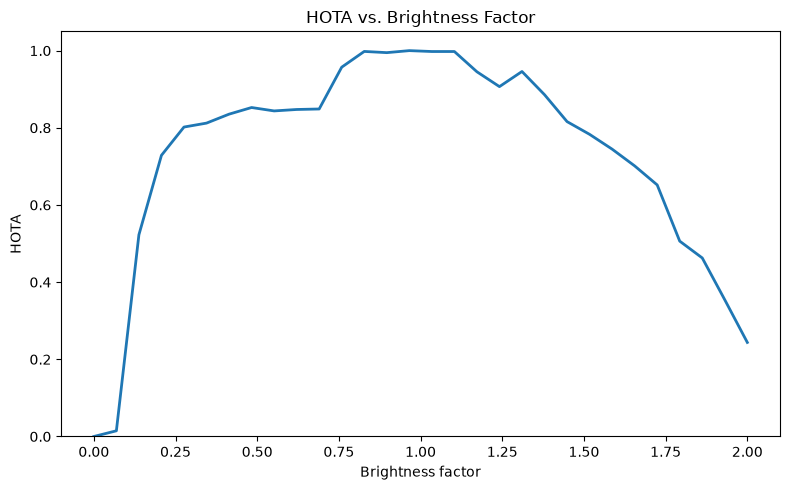

In [15]:
hota_list = [m["HOTA"] for m in perturbed_metrics]

plt.figure(figsize=(8, 5))
plt.plot(factor_sweep, hota_list, linewidth=2)
plt.xlabel("Brightness factor")
plt.ylabel("HOTA")
plt.title("HOTA vs. Brightness Factor")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Evaluation Interpretation

In general, we observe a perturbation value range between around 0.5 and 1.4 where the score is about 0.80 or higher, and sharp falloffs when the perturbation factor is below roughly 0.25 or above 1.4. We also observe the peak HOTA values near a factor of 1.0. This makes sense since brightness factors close to 1.0 produce videos similar to the unperturbed video.

### Additional Plot

For further insight, we can plot the HOTA components separately.

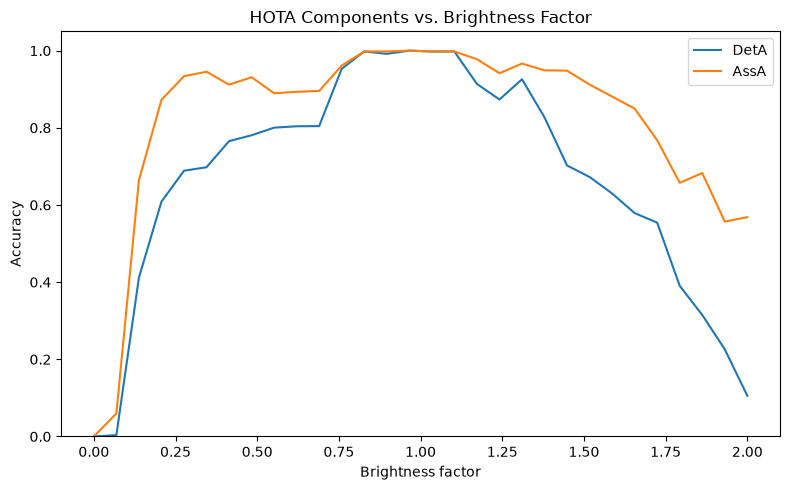

In [16]:
plt.figure(figsize=(8, 5))
plt.title("HOTA Components vs. Brightness Factor")
plt.xlabel("Brightness factor")
plt.ylabel("Accuracy")
for k in ("DetA", "AssA"):
    plt.plot(factor_sweep, [m[k] for m in perturbed_metrics], label=k)
plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

HOTA can be broken down into its two main components: Detection Accuracy (DetA) and Association Accuracy (AssA). We observe the two plots follow each other closely from 0.0 to 1.5. AssA is always higher than DetA. This make sense in the context of changing the brightness of a video. Once an object is detected, it is likely to stay detected since brightness is consistent across each frame of the video. Once we move past a brightness factor of 1.5, we notice a divergence of DetA and AssA. DetA drops quicker and continues to drop while AssA drops slowly and somewhat stabelizes past 1.75. This follows the previous observation about the brightness perturbation.

## End of Notebook